In [ ]:
# 이름 평가수 평가인원 금액

In [5]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
import requests
from bs4 import BeautifulSoup
import time
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic' # 한글처리 window 맑은고딕이 디폴트로 저장되어있음
# matplotlib.rcParams['font.family'] = 'AppleGothic' # 한글처리 mac 애플고딕이 디폴트로 저장되어있음
matplotlib.rcParams['font.size'] = 15
matplotlib.rcParams['axes.unicode_minus'] = False # -(마이너스)부호 처리

In [ ]:
# # 2. selenium : 자동화 도구
# browser = webdriver.Chrome()
# url = "https://www.yeogi.com/domestic-accommodations?sortType=RECOMMEND&keyword=%EA%B2%BD%EC%A3%BC&personal=2&checkIn=2026-10-08&checkOut=2026-10-09&category=2&autoKeyword=%EA%B2%BD%EB%B6%81+%EA%B2%BD%EC%A3%BC%EC%8B%9C"
# # 브라우저 열기
# browser.get(url)
# time.sleep(4)
# # 파일저장
# soup = BeautifulSoup(browser.page_source,'lxml')
# with open('file/trip.html','w',encoding='utf-8') as f:
#     f.write(soup.prettify())

# 파일 BeautifulSoup변환
# with open('trip.html','r',encoding='utf-8') as f:
#     soup = BeautifulSoup(f,'lxml')

#------------------------------------

# s_headTitle = []
# s_tbody = soup.tbody
# # trs = s_tbody.find('tr')      # 1개 sk하이닉스 find,find_all
# trs = s_tbody.find_all('tr')  # 100개 정보
# for tr in trs:
#     tds = tr.find_all('td')      # td 8개
#     s_idx = tds[0].find('span',{'class':'index'}).get_text(strip=True)
#     s_title = tds[0].find('span',{'class':'SingleLineText_text__HI_cb'})
#     s_title = s_title.get_text(strip=True)
#     s_price = tds[1].find('span',{'class':'SingleLinePrice_price__g_6VV'})
#     s_price = s_price.get_text(strip=True)
#     s_compare = tds[2].find('span',{'class':'ModulePriceChange_amount__4QYMz'})
#     s_compare = s_compare.get_text(strip=True)
#     s_trade = tds[3].find('span',{'class':'SingleLinePrice_price__g_6VV'})
#     s_trade = s_trade.get_text(strip=True)
#     s_trade_val = tds[4].find('span',{'class':'SingleLinePrice_price__g_6VV'})
#     s_trade_val = s_trade_val.get_text(strip=True)
#     s_costliness = tds[5].find('span',{'class':'SingleLinePrice_price__g_6VV'})
#     s_costliness = s_costliness.get_text(strip=True)
#     s_lowprice = tds[6].find('span',{'class':'SingleLinePrice_price__g_6VV'})
#     s_lowprice = s_lowprice.get_text(strip=True)
#     s_cap = tds[7].find('span',{'class':'SingleLineText_text__HI_cb'})
#     s_cap = s_cap.get_text(strip=True)
#     print(f"{s_idx}.{s_title}\t{s_price}\t{s_compare}\t{s_trade}\t{s_trade_val}\t{s_costliness}\t{s_lowprice}\t{s_cap}")
#     print("-"*85)




# # 2-2. selenium : 자동화 도구 - 스크롤 사용
# url = "https://www.yeogi.com/domestic-accommodations?keyword=%EA%B2%BD%EC%A3%BC&personal=2&checkIn=2026-10-08&checkOut=2026-10-09&category=2&sortType=RECOMMEND"
# options = Options()
# options.add_experimental_option("excludeSwitches", ["enable-automation"])
# options.add_experimental_option("useAutomationExtension", False)
# options.add_argument("--disable-blink-features=AutomationControlled")
# browser = webdriver.Chrome(options=options)
# browser.maximize_window() # 화면 최대창 확대
# browser.get(url)
# time.sleep(2)

# # 현재 스크롤 높이 가져옴
# prev_height = browser.execute_script("return document.body.scrollHeight")

# while True:
#     # 스크롤 높이 출력
#     print('높이 : ',prev_height)
#     # 스크롤 내리기
#     browser.execute_script("window.scrollTo(0,document.body.scrollHeight)")
#     time.sleep(2)
#     # 스크롤이 추가 되었는지 확인
#     next_height = browser.execute_script("return document.body.scrollHeight")
#     if prev_height == next_height:
#         break
#     prev_height = next_height





In [6]:
with open('file/trip.html','r',encoding='utf-8') as f:
    soup = BeautifulSoup(f,'lxml')

In [18]:
ul = soup.find('ul',{'class','css-y5z6rw'})

lis = ul.find_all('li',{'class','gc-thumbnail-type-seller-card-wrapper css-13wylk3'})
# size = lis[0].find('span',{'class','css-144z61f'}).get_text(strip=True)
# size1 = int(size[:-4].replace(',',''))
# price = lis[0].find('span',{'class','css-1llao6q'}).get_text(strip=True)
# price = int(price.replace(',',""))
# print(price)
data =[]
for i in range(len(lis)):
        try:
            name = lis[i].find('h3',{'class','gc-thumbnail-type-seller-card-title css-1gsfgy5'}).get_text(strip=True)
            avg = lis[i].find('span',{'class','css-ry30z7'}).get_text(strip=True)
            avg = float(avg)
            size = lis[i].find('span',{'class','css-144z61f'}).get_text(strip=True)
            size1 = int(size[:-4].replace(',',''))
            price = lis[i].find('span',{'class','css-1llao6q'}).get_text(strip=True)
            price = int(price.replace(',',""))
        except:pass
        data.append({
        '숙소명':name,
        '평점':avg,
        '평가수':size1,
        '금액':price
    })
df = pd.DataFrame(data)
df



,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,10361,202400
1,오소한옥스테이,9.8,154,325000
2,소노캄 경주,8.8,872,368000
3,라한셀렉트 경주,9.4,3003,388050
4,소노벨 경주 감포,9.1,2295,105000
5,경주시티호텔,9.7,294,303600
6,경주 코모도호텔,9.0,1462,164680
7,이제 경주,9.5,778,325500
8,경주 코오롱호텔,8.0,644,113170
9,란타나호텔 경주불국사점,10.0,8,89000


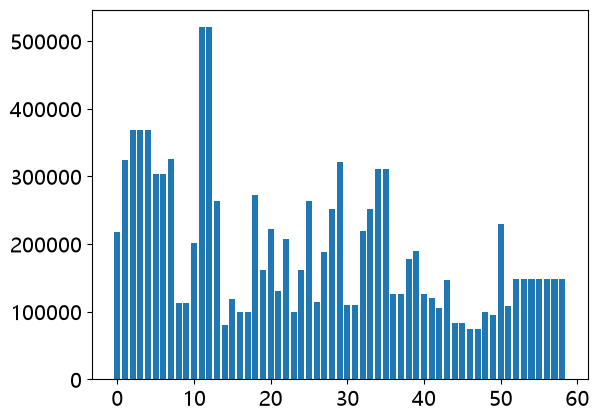

In [84]:
x = df.index
y = df['금액']
plt.bar(x,y)
plt.show()

In [ ]:
data =[]
data.append({
    '숙소명':'힐튼 경주',
    '평점':9.4,
    '평가수':'10,361',
    '금액':'202,400'
})